# Human Evaluation Analysis

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

In [1]:
import os, json, re, warnings, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
BBOX_RESULTS_PATH  = 'evaluation/bbox_results.json'
VARIANT_A_BASE_DIR = 'multimodal/variant_a'
VARIANT_B_BASE_DIR = 'multimodal/variant_b'
RESULTS_BASE_DIR   = 'results/selection'
OUTPUT_DIR         = 'evaluation/human_eval'

os.makedirs(OUTPUT_DIR, exist_ok=True)

QWEN_SCALE_FACTOR = 1000

SCENE_TYPE_MAP = {
    'single/solo': 'Isolated', 'single_solo': 'Isolated',
    'single/multi': 'Clustered', 'single_multi': 'Clustered',
    'multi': 'Mixed',
}
SCENE_ORDER  = ['Isolated', 'Clustered', 'Mixed']
SCENE_COLORS = {'Isolated': '#42A5F5', 'Clustered': '#66BB6A', 'Mixed': '#EF5350'}
METHOD_ORDER  = ['l2', 'swad']
VARIANT_ORDER = ['variant_a', 'variant_b']
METHOD_NICE   = {'l2': 'L2', 'swad': 'SWAD*'}
VARIANT_NICE  = {'variant_a': 'Variant A', 'variant_b': 'Variant B'}

## Load & Flatten Human Annotations

In [3]:
with open(BBOX_RESULTS_PATH) as f:
    bbox_results = json.load(f)
print(f'Loaded {len(bbox_results)} images from bbox_results.json')

Loaded 312 images from bbox_results.json


In [4]:
label_records = []

for filename, img_data in bbox_results.items():
    img_w = img_data['image_width']
    img_h = img_data['image_height']
    internal_mapping = img_data['internal_mapping']
    parts = internal_mapping.rsplit('/', 1)
    category_path = parts[0]
    folder_id     = parts[1]
    scene_type    = SCENE_TYPE_MAP.get(category_path, 'Unknown')
    
    for ann in img_data['annotations']:
        for lbl in ann['labels']:
            resp_type = lbl['response_type']
            reject_reason = lbl.get('reject_reason', None)
            if resp_type == 'reject' and reject_reason not in ('unclear_image', 'unclear_label'):
                resp_type = 'skip'
            
            rec = {
                'filename': filename, 'image_width': img_w, 'image_height': img_h,
                'internal_mapping': internal_mapping,
                'category_path': category_path, 'folder_id': folder_id,
                'scene_type': scene_type,
                'session_id': ann['session'], 'method': ann['method'],
                'variant': ann['variant'],
                'label': lbl['label'], 'label_index': lbl['label_index'],
                'total_labels': lbl['total_labels'],
                'response_type': resp_type,
                'reject_reason': reject_reason if resp_type == 'reject' else None,
                'num_bboxes': lbl.get('num_bboxes', 0) if lbl['response_type'] == 'bbox' else 0,
                'bboxes': lbl.get('bboxes', []) if lbl['response_type'] == 'bbox' else [],
            }
            label_records.append(rec)

df_all = pd.DataFrame(label_records)
print(f'Total label entries: {len(df_all)}')
print(df_all['response_type'].value_counts())
n_skip = (df_all.response_type == 'skip').sum()
print(f'\n-> {n_skip} skip responses will be EXCLUDED from analysis.')

Total label entries: 705
response_type
bbox      502
reject    161
skip       42
Name: count, dtype: int64

-> 42 skip responses will be EXCLUDED from analysis.


In [5]:
df_labels = df_all[df_all.response_type != 'skip'].copy().reset_index(drop=True)

n_total  = len(df_labels)
n_bbox   = (df_labels.response_type == 'bbox').sum()
n_reject = (df_labels.response_type == 'reject').sum()
reject_img = (df_labels.reject_reason == 'unclear_image').sum()
reject_lbl = (df_labels.reject_reason == 'unclear_label').sum()

print(f'After excluding skip: {n_total} label entries')
print(f'  bbox:   {n_bbox} ({100*n_bbox/n_total:.1f}%)')
print(f'  reject: {n_reject} ({100*n_reject/n_total:.1f}%)')
print(f'    Image unclear: {reject_img} ({100*reject_img/n_reject:.1f}%)')
print(f'    Label unclear: {reject_lbl} ({100*reject_lbl/n_reject:.1f}%)')

After excluding skip: 663 label entries
  bbox:   502 (75.7%)
  reject: 161 (24.3%)
    Image unclear: 46 (28.6%)
    Label unclear: 115 (71.4%)


## Load VLM Results & Extract Metrics

In [6]:
RESULT_FILE_MAP = {'l2': 'best_l2_result.json', 'swad': 'best_swad_result.json'}

def load_vlm_result(category_path, folder_id, variant, method):
    base = VARIANT_A_BASE_DIR if variant == 'variant_a' else VARIANT_B_BASE_DIR
    path = os.path.join(base, category_path, folder_id, RESULT_FILE_MAP[method])
    if not os.path.exists(path): return None
    with open(path) as f: return json.load(f)

vlm_cache = {}
unique_conds = df_labels[['category_path','folder_id','variant','method']].drop_duplicates()
for _, r in unique_conds.iterrows():
    key = (r['category_path'], r['folder_id'], r['variant'], r['method'])
    vlm_cache[key] = load_vlm_result(*key)

print(f'Loaded {sum(1 for v in vlm_cache.values() if v is not None)}/{len(vlm_cache)} VLM results')

Loaded 411/411 VLM results


In [7]:
def extract_prompt_labels(prompt):
    m = re.search(r'objects\s+"(.*?)"', prompt)
    if not m: m = re.search(r'"([^"]+)"', prompt)
    if not m: return []
    return [lbl.strip() for lbl in m.group(1).split(',')]

enriched = []
for _, row in df_labels.iterrows():
    key = (row['category_path'], row['folder_id'], row['variant'], row['method'])
    result = vlm_cache.get(key)
    rec = dict(row)
    
    if result is None:
        for c in ['vlm_iou','vlm_d_I','vlm_d_T','vlm_phi','vlm_swad','vlm_delta_m','vlm_baseline_iou']:
            rec[c] = np.nan
        rec.update({'gt_bboxes':{},'original_labels':[],'corrupted_labels':[],
                    'img_attack':None,'img_scale':np.nan,'txt_attack':None,'txt_scale':np.nan,
                    'max_img_scale':np.nan,'n_active_img':0,'n_active_txt':0,
                    'img_budget_used':np.nan,'txt_budget_used':np.nan})
        enriched.append(rec); continue
    
    rec['vlm_iou']          = result['objectives']['iou']
    rec['vlm_d_I']          = result['objectives']['img_dist']
    rec['vlm_d_T']          = result['objectives']['txt_dist']
    rec['vlm_phi']          = result['swad_metrics']['phi']
    rec['vlm_swad']         = result['swad_metrics']['swad']
    rec['vlm_delta_m']      = result['swad_metrics']['delta_m_plus']
    rec['vlm_baseline_iou'] = result['swad_metrics']['iou_0']
    rec['gt_bboxes']        = result.get('ground_truth_bboxes', {})
    rec['original_labels']  = extract_prompt_labels(result.get('original_prompt', ''))
    rec['corrupted_labels'] = extract_prompt_labels(
        result.get('vlm_output', {}).get('adversarial_prompt', ''))
    
    genome = result.get('genome', {})
    if row['variant'] == 'variant_a':
        rec['img_attack'] = genome.get('img_attack')
        rec['img_scale'] = rec['max_img_scale'] = genome.get('img_scale', np.nan)
        rec['txt_attack'] = genome.get('txt_attack')
        rec['txt_scale'] = genome.get('txt_scale', np.nan)
        rec['n_active_img'] = rec['n_active_txt'] = 1
    else:
        ic = genome.get('image_corruptions', {})
        tc = genome.get('text_corruptions', {})
        if ic:
            rec['img_attack'] = max(ic, key=ic.get)
            rec['img_scale'] = rec['max_img_scale'] = max(ic.values())
            rec['n_active_img'] = sum(1 for v in ic.values() if v > 0.01)
        else:
            rec['img_attack']=None; rec['img_scale']=rec['max_img_scale']=np.nan; rec['n_active_img']=0
        if tc:
            rec['txt_attack'] = max(tc, key=tc.get)
            rec['txt_scale'] = max(tc.values())
            rec['n_active_txt'] = sum(1 for v in tc.values() if v > 0.01)
        else:
            rec['txt_attack']=None; rec['txt_scale']=np.nan; rec['n_active_txt']=0
    rec['img_budget_used'] = genome.get('img_budget_used', np.nan)
    rec['txt_budget_used'] = genome.get('txt_budget_used', np.nan)
    enriched.append(rec)

df_labels = pd.DataFrame(enriched)
print(f'Matched {df_labels.vlm_iou.notna().sum()}/{len(df_labels)} to VLM results')

Matched 663/663 to VLM results


## Compute Human IoU

In [8]:
def calculate_iou(a, b):
    xa,ya,xb,yb = max(a[0],b[0]),max(a[1],b[1]),min(a[2],b[2]),min(a[3],b[3])
    inter = max(0,xb-xa)*max(0,yb-ya)
    area = max(0,a[2]-a[0])*max(0,a[3]-a[1]) + max(0,b[2]-b[0])*max(0,b[3]-b[1]) - inter
    return inter/area if area > 0 else 0.0

def _norm(t):
    if not isinstance(t,str): return ''
    return re.sub(r'[\s\u200b\u200d]+','',t).lower()

def labels_match(a,b):
    na,nb = _norm(a),_norm(b)
    if na==nb: return True
    if sorted(na)==sorted(nb): return True
    return difflib.SequenceMatcher(None,na,nb).ratio() >= 0.75

def compute_human_iou_for_label(row):
    gt = row['gt_bboxes']
    cl = row['label']
    orig = row['original_labels'] if isinstance(row['original_labels'],list) else []
    corrupt = row['corrupted_labels'] if isinstance(row['corrupted_labels'],list) else []
    
    target_orig = None
    for i,c in enumerate(corrupt):
        if labels_match(cl,c) and i<len(orig):
            target_orig = orig[i]; break
    
    mg = []
    if gt:
        for k,v in gt.items():
            gc = k.rsplit('_',1)[0] if '_' in k else k
            if (target_orig and labels_match(gc,target_orig)) or labels_match(gc,cl):
                mg.append([v['xmin'],v['ymin'],v['xmax'],v['ymax']])
        if not mg and len(gt)==1:
            for v in gt.values(): mg.append([v['xmin'],v['ymin'],v['xmax'],v['ymax']])
    
    n_gt = max(len(mg),1)
    if row['response_type']=='reject': return 0.0, n_gt
    hb = row['bboxes']
    if not hb or not mg: return 0.0, n_gt
    hbc = [[b['xmin'],b['ymin'],b['xmax'],b['ymax']] for b in hb]
    ious = [max((calculate_iou(g,h) for h in hbc), default=0.0) for g in mg]
    return np.mean(ious) if ious else 0.0, len(mg)

res = df_labels.apply(compute_human_iou_for_label, axis=1)
df_labels['human_iou'] = [r[0] for r in res]
df_labels['n_matched_gt'] = [r[1] for r in res]

bb = df_labels[df_labels.response_type=='bbox']
print(f'Human IoU: All={df_labels.human_iou.mean():.4f}, '
      f'Bbox-only={bb.human_iou.mean():.4f}')

Human IoU: All=0.5480, Bbox-only=0.7237


In [9]:
df_sess = df_labels.groupby(
    ['filename','session_id','scene_type','method','variant','category_path','folder_id']
).agg(
    human_iou_mean=('human_iou','mean'),
    human_iou_bbox_only=('human_iou', lambda x: x[df_labels.loc[x.index,'response_type']=='bbox'].mean() if (df_labels.loc[x.index,'response_type']=='bbox').any() else np.nan),
    n_labels=('label','count'),
    n_bbox=('response_type', lambda x: (x=='bbox').sum()),
    n_reject=('response_type', lambda x: (x=='reject').sum()),
    vlm_iou=('vlm_iou','first'), vlm_d_I=('vlm_d_I','first'),
    vlm_d_T=('vlm_d_T','first'), vlm_phi=('vlm_phi','first'),
    vlm_swad=('vlm_swad','first'), vlm_delta_m=('vlm_delta_m','first'),
    vlm_baseline_iou=('vlm_baseline_iou','first'),
    img_scale=('img_scale','first'), max_img_scale=('max_img_scale','first'),
).reset_index()

df_sess['gap'] = df_sess.human_iou_mean - df_sess.vlm_iou
df_sess['all_rejected'] = df_sess.n_reject == df_sess.n_labels

print(f'Image-level annotations: {len(df_sess)}')

Image-level annotations: 446


## Annotation Statistics

In [10]:
n_images = len(bbox_results)
n_annotator_sessions = df_all.session_id.nunique()    # unique UUID sessions (~42)
n_image_annotations  = len(df_all.groupby(['filename','session_id']))  # image-level (~477)

print('='*70)
print('ANNOTATION STATISTICS')
print('='*70)
print(f'Unique images annotated:          {n_images}')
print(f'Annotator sessions (12-image):    {n_annotator_sessions}')
print(f'Image-level annotations:          {n_image_annotations}')
print(f'Total label entries (raw):        {len(df_all)}')
print(f'  Skip excluded:                  {n_skip}')
print(f'  Analysed entries:               {n_total}')
print(f'    Bounding box:                 {n_bbox} ({100*n_bbox/n_total:.1f}%)')
print(f'    Rejected:                     {n_reject} ({100*n_reject/n_total:.1f}%)')
print(f'      Image unclear:              {reject_img} ({100*reject_img/n_reject:.1f}%)')
print(f'      Label unclear:              {reject_lbl} ({100*reject_lbl/n_reject:.1f}%)')

ANNOTATION STATISTICS
Unique images annotated:          312
Annotator sessions (12-image):    42
Image-level annotations:          477
Total label entries (raw):        705
  Skip excluded:                  42
  Analysed entries:               663
    Bounding box:                 502 (75.7%)
    Rejected:                     161 (24.3%)
      Image unclear:              46 (28.6%)
      Label unclear:              115 (71.4%)


In [11]:
print('\n=== Per-Condition Cell ===')
print(f'{"Scene":<12} {"Method":<8} {"Variant":<12} {"Total":>5} '
      f'{"BBox":>5} {"Rej":>5} {"Rej%":>6} {"ImgR":>5} {"LblR":>5}')
print('-'*70)

cell_records = []
for st in SCENE_ORDER:
    for method in METHOD_ORDER:
        for variant in VARIANT_ORDER:
            mask = (df_labels.scene_type==st)&(df_labels.method==method)&(df_labels.variant==variant)
            sub = df_labels[mask]
            t = len(sub); bb = (sub.response_type=='bbox').sum()
            rj = (sub.response_type=='reject').sum()
            ri = (sub.reject_reason=='unclear_image').sum()
            rl = (sub.reject_reason=='unclear_label').sum()
            rp = 100*rj/t if t>0 else 0
            cell_records.append(dict(scene_type=st,method=method,variant=variant,
                                     total=t,bbox=bb,reject=rj,reject_pct=rp,
                                     reject_image=ri,reject_label=rl))
            print(f'{st:<12} {METHOD_NICE[method]:<8} {VARIANT_NICE[variant]:<12} '
                  f'{t:>5} {bb:>5} {rj:>5} {rp:>5.1f}% {ri:>5} {rl:>5}')

df_cells = pd.DataFrame(cell_records)


=== Per-Condition Cell ===
Scene        Method   Variant      Total  BBox   Rej   Rej%  ImgR  LblR
----------------------------------------------------------------------
Isolated     L2       Variant A       37    29     8  21.6%     3     5
Isolated     L2       Variant B       38    30     8  21.1%     2     6
Isolated     SWAD*    Variant A       34    23    11  32.4%     6     5
Isolated     SWAD*    Variant B       36    28     8  22.2%     1     7
Clustered    L2       Variant A       39    26    13  33.3%     2    11
Clustered    L2       Variant B       40    34     6  15.0%     1     5
Clustered    SWAD*    Variant A       35    26     9  25.7%     3     6
Clustered    SWAD*    Variant B       37    25    12  32.4%     1    11
Mixed        L2       Variant A      104    71    33  31.7%    15    18
Mixed        L2       Variant B       80    65    15  18.8%     3    12
Mixed        SWAD*    Variant A       90    65    25  27.8%     7    18
Mixed        SWAD*    Variant B      

In [12]:
print('\n=== Inter-Annotator Agreement ===')

# Find images annotated by multiple sessions under the same condition
overlap = df_sess.groupby(['filename','method','variant']).agg(
    n_annotators=('session_id','nunique'),
    iou_values=('human_iou_mean', list),
    reject_flags=('all_rejected', list),
).reset_index()

multi = overlap[overlap.n_annotators > 1].copy()
print(f'(image × method × variant) with >1 annotator: {len(multi)}')

if len(multi) > 0:
    iou_diffs = []
    reject_agreements = []
    for _, row in multi.iterrows():
        vals = row['iou_values']
        flags = row['reject_flags']
        for i in range(len(vals)):
            for j in range(i+1, len(vals)):
                iou_diffs.append(abs(vals[i] - vals[j]))
            reject_agreements.append(len(set(flags)) == 1)
    
    print(f'Pairwise IoU absolute differences: {len(iou_diffs)} pairs')
    print(f'  Mean |Δ IoU|:    {np.mean(iou_diffs):.4f}')
    print(f'  Median |Δ IoU|:  {np.median(iou_diffs):.4f}')
    print(f'  Max |Δ IoU|:     {np.max(iou_diffs):.4f}')
    
    agree_pct = 100 * np.mean(reject_agreements)
    print(f'\nRejection agreement (all annotators same accept/reject): '
          f'{agree_pct:.1f}% ({sum(reject_agreements)}/{len(reject_agreements)})')
    
    print(f'\nMulti-annotated condition breakdown:')
    for n in sorted(multi.n_annotators.unique()):
        sub = multi[multi.n_annotators == n]
        print(f'  {n} annotators: {len(sub)} conditions')
else:
    print('No overlapping annotations found.')


=== Inter-Annotator Agreement ===
(image × method × variant) with >1 annotator: 34
Pairwise IoU absolute differences: 36 pairs
  Mean |Δ IoU|:    0.3167
  Median |Δ IoU|:  0.2238
  Max |Δ IoU|:     0.9622

Rejection agreement (all annotators same accept/reject): 73.9% (51/69)

Multi-annotated condition breakdown:
  2 annotators: 33 conditions
  3 annotators: 1 conditions


## Human vs. VLM Detection Performance

In [13]:
s = df_sess.dropna(subset=['vlm_iou'])

print('='*70)
print('HUMAN vs VLM DETECTION PERFORMANCE')
print('='*70)
print(f'{"":20} {"Human":>10} {"VLM":>10} {"Gap":>10} {"N":>5}')
print('-'*58)
for st in SCENE_ORDER:
    sub = s[s.scene_type==st]
    print(f'{st:<20} {sub.human_iou_mean.mean():>10.4f} {sub.vlm_iou.mean():>10.4f} '
          f'{sub.gap.mean():>+10.4f} {len(sub):>5}')
print('-'*58)
print(f'{"Overall":<20} {s.human_iou_mean.mean():>10.4f} {s.vlm_iou.mean():>10.4f} '
      f'{s.gap.mean():>+10.4f} {len(s):>5}')

stat, pval = stats.wilcoxon(s.human_iou_mean, s.vlm_iou, alternative='greater')
d = (s.human_iou_mean - s.vlm_iou)
print(f'\nWilcoxon (human > VLM): stat={stat:.0f}, p={pval:.2e}')
print(f'Cohen\'s d = {d.mean()/d.std():.3f} (paired)')

HUMAN vs VLM DETECTION PERFORMANCE
                          Human        VLM        Gap     N
----------------------------------------------------------
Isolated                 0.6408     0.1651    +0.4757   145
Clustered                0.5365     0.1050    +0.4315   150
Mixed                    0.5170     0.0458    +0.4713   151
----------------------------------------------------------
Overall                  0.5638     0.1045    +0.4593   446

Wilcoxon (human > VLM): stat=76244, p=2.56e-57
Cohen's d = 1.197 (paired)


In [14]:
s_bbox = df_sess.dropna(subset=['human_iou_bbox_only'])

print('\n=== Bbox-Only Human IoU (image-level, excluding fully-rejected images) ===')
print('(Answers: when a human CAN detect, how accurately do they localize?)')
print(f'\n{"":20} {"BBox IoU":>10} {"All IoU":>10} {"N images":>10}')
print('-'*54)

for st in SCENE_ORDER:
    sub_bb = s_bbox[s_bbox.scene_type == st]
    sub_all = s[s.scene_type == st]
    print(f'{st:<20} {sub_bb.human_iou_bbox_only.mean():>10.4f} '
          f'{sub_all.human_iou_mean.mean():>10.4f} {len(sub_bb):>10}')

print('-'*54)
print(f'{"Overall":<20} {s_bbox.human_iou_bbox_only.mean():>10.4f} '
      f'{s.human_iou_mean.mean():>10.4f} {len(s_bbox):>10}')

print(f'\n--- Bbox-Only IoU per Condition Cell ---')
print(f'{"Scene":<12} {"Method":<8} {"Variant":<12} {"N":>4} {"BBox IoU":>10}')
print('-'*50)
for st in SCENE_ORDER:
    for method in METHOD_ORDER:
        for variant in VARIANT_ORDER:
            mask = (s_bbox.scene_type==st)&(s_bbox.method==method)&(s_bbox.variant==variant)
            sub = s_bbox[mask]
            if len(sub)==0: continue
            print(f'{st:<12} {METHOD_NICE[method]:<8} {VARIANT_NICE[variant]:<12} '
                  f'{len(sub):>4} {sub.human_iou_bbox_only.mean():>10.4f}')


=== Bbox-Only Human IoU (image-level, excluding fully-rejected images) ===
(Answers: when a human CAN detect, how accurately do they localize?)

                       BBox IoU    All IoU   N images
------------------------------------------------------
Isolated                 0.8446     0.6408        110
Clustered                0.7316     0.5365        110
Mixed                    0.6796     0.5170        138
------------------------------------------------------
Overall                  0.7463     0.5638        358

--- Bbox-Only IoU per Condition Cell ---
Scene        Method   Variant         N   BBox IoU
--------------------------------------------------
Isolated     L2       Variant A      29     0.8250
Isolated     L2       Variant B      30     0.8715
Isolated     SWAD*    Variant A      23     0.8134
Isolated     SWAD*    Variant B      28     0.8619
Clustered    L2       Variant A      25     0.7476
Clustered    L2       Variant B      34     0.7221
Clustered    SWAD*    Va

In [15]:
print('\n=== Human vs VLM IoU per Condition Cell ===')
print(f'{"Scene":<12} {"Method":<8} {"Variant":<12} {"N":>4} '
      f'{"Human":>8} {"VLM":>8} {"Gap":>8}')
print('-'*66)
for st in SCENE_ORDER:
    for method in METHOD_ORDER:
        for variant in VARIANT_ORDER:
            mask = (s.scene_type==st)&(s.method==method)&(s.variant==variant)
            sub = s[mask]
            if len(sub)==0: continue
            print(f'{st:<12} {METHOD_NICE[method]:<8} {VARIANT_NICE[variant]:<12} '
                  f'{len(sub):>4} {sub.human_iou_mean.mean():>8.4f} '
                  f'{sub.vlm_iou.mean():>8.4f} {sub.gap.mean():>+8.4f}')


=== Human vs VLM IoU per Condition Cell ===
Scene        Method   Variant         N    Human      VLM      Gap
------------------------------------------------------------------
Isolated     L2       Variant A      37   0.6466   0.2569  +0.3897
Isolated     L2       Variant B      38   0.6880   0.1290  +0.5591
Isolated     SWAD*    Variant A      34   0.5502   0.1367  +0.4136
Isolated     SWAD*    Variant B      36   0.6704   0.1357  +0.5347
Clustered    L2       Variant A      38   0.4918   0.1337  +0.3581
Clustered    L2       Variant B      40   0.6138   0.1195  +0.4942
Clustered    SWAD*    Variant A      35   0.5267   0.0952  +0.4316
Clustered    SWAD*    Variant B      37   0.5081   0.0690  +0.4390
Mixed        L2       Variant A      41   0.4689   0.0707  +0.3982
Mixed        L2       Variant B      36   0.5188   0.0185  +0.5003
Mixed        SWAD*    Variant A      37   0.5012   0.0736  +0.4275
Mixed        SWAD*    Variant B      37   0.5845   0.0167  +0.5678


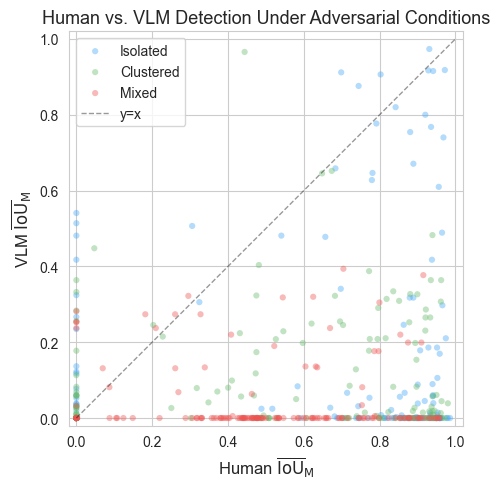

In [16]:
fig, ax = plt.subplots(figsize=(5,5))
for st in SCENE_ORDER:
    sub = s[s.scene_type==st]
    ax.scatter(sub.human_iou_mean, sub.vlm_iou, alpha=0.4, s=20,
               color=SCENE_COLORS[st], label=st, edgecolors='none')
ax.plot([0,1],[0,1],'k--',alpha=0.4,lw=1,label='y=x')
ax.set_xlabel('Human $\\overline{\\mathrm{IoU}}_\\mathrm{M}$',fontsize=12); ax.set_ylabel('VLM $\\overline{\\mathrm{IoU}}_\\mathrm{M}$',fontsize=12)
ax.set_title('Human vs. VLM Detection Under Adversarial Conditions',fontsize=13)
ax.legend(fontsize=10); ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'fig_human_vs_vlm_scatter.pdf'),dpi=150)
plt.show()

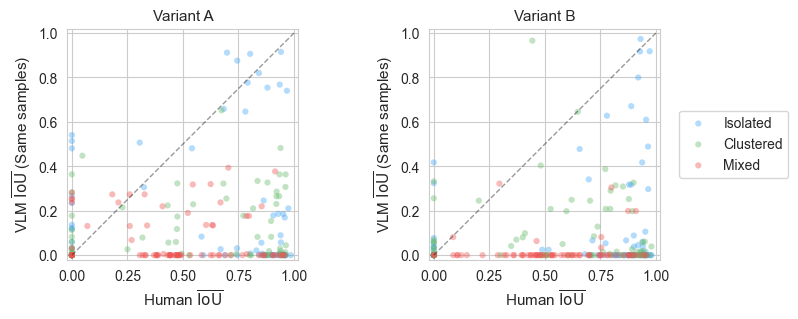

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))

for ax, variant, title in zip(axes, VARIANT_ORDER, ['Variant A', 'Variant B']):
    sub_v = s[s.variant == variant]
    for st in SCENE_ORDER:
        sub = sub_v[sub_v.scene_type == st]
        ax.scatter(sub.human_iou_mean, sub.vlm_iou, alpha=0.4, s=20,
                   color=SCENE_COLORS[st], label=st, edgecolors='none')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
    ax.set_xlabel('Human $\\overline{\\mathrm{IoU}}$', fontsize=11)
    ax.set_ylabel('VLM $\\overline{\\mathrm{IoU}}$ (Same samples)', fontsize=11)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    h_mean = sub_v.human_iou_mean.mean()
    v_mean = sub_v.vlm_iou.mean()
    ax.set_title(f'{title}',
                 fontsize=11)

axes[1].legend(fontsize=10, loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1)
fig.subplots_adjust(left=0.08, right=0.78, wspace=0.35)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_human_vs_vlm_scatter_by_variant.pdf'),
            dpi=200, bbox_inches='tight')
plt.show()

## Variant A vs. Variant B -- Human Perspective

In [18]:
print('='*70)
print('VARIANT A vs VARIANT B -- HUMAN PERSPECTIVE')
print('='*70)

print(f'\n--- Human IoU (session-level, reject=0) ---')
print(f'{"":20} {"A":>10} {"B":>10} {"Δ(A−B)":>10}')
print('-'*52)
for st in SCENE_ORDER:
    ha = s[(s.scene_type==st)&(s.variant=='variant_a')].human_iou_mean.mean()
    hb = s[(s.scene_type==st)&(s.variant=='variant_b')].human_iou_mean.mean()
    print(f'{st:<20} {ha:>10.4f} {hb:>10.4f} {ha-hb:>+10.4f}')
ha_all = s[s.variant=='variant_a'].human_iou_mean.mean()
hb_all = s[s.variant=='variant_b'].human_iou_mean.mean()
print('-'*52)
print(f'{"Overall":<20} {ha_all:>10.4f} {hb_all:>10.4f} {ha_all-hb_all:>+10.4f}')

stat,pval = stats.mannwhitneyu(
    s[s.variant=='variant_a'].human_iou_mean,
    s[s.variant=='variant_b'].human_iou_mean, alternative='two-sided')
n1 = (s.variant=='variant_a').sum(); n2 = (s.variant=='variant_b').sum()
print(f'Mann-Whitney U={stat:.0f}, p={pval:.4f}, rank-biserial r={1-(2*stat)/(n1*n2):.3f}')

VARIANT A vs VARIANT B -- HUMAN PERSPECTIVE

--- Human IoU (session-level, reject=0) ---
                              A          B     Δ(A−B)
----------------------------------------------------
Isolated                 0.6004     0.6794    -0.0790
Clustered                0.5086     0.5630    -0.0544
Mixed                    0.4842     0.5521    -0.0679
----------------------------------------------------
Overall                  0.5294     0.5979    -0.0685
Mann-Whitney U=22483, p=0.0790, rank-biserial r=0.096


In [19]:
print(f'\n--- Bbox-Only Human IoU: A vs B (image-level) ---')
print('(Excluding fully-rejected images -- "when they CAN detect, how well?")')
print(f'{"":20} {"A":>10} {"B":>10} {"Δ(A−B)":>10}')
print('-'*52)
for st in SCENE_ORDER:
    a_bb = s_bbox[(s_bbox.scene_type==st)&(s_bbox.variant=='variant_a')].human_iou_bbox_only.mean()
    b_bb = s_bbox[(s_bbox.scene_type==st)&(s_bbox.variant=='variant_b')].human_iou_bbox_only.mean()
    print(f'{st:<20} {a_bb:>10.4f} {b_bb:>10.4f} {a_bb-b_bb:>+10.4f}')
a_bb_all = s_bbox[s_bbox.variant=='variant_a'].human_iou_bbox_only.mean()
b_bb_all = s_bbox[s_bbox.variant=='variant_b'].human_iou_bbox_only.mean()
print('-'*52)
print(f'{"Overall":<20} {a_bb_all:>10.4f} {b_bb_all:>10.4f} {a_bb_all-b_bb_all:>+10.4f}')

stat,p = stats.mannwhitneyu(
    s_bbox[s_bbox.variant=='variant_a'].human_iou_bbox_only,
    s_bbox[s_bbox.variant=='variant_b'].human_iou_bbox_only, alternative='two-sided')
print(f'Mann-Whitney (bbox-only, image-level): U={stat:.0f}, p={p:.4f}')


--- Bbox-Only Human IoU: A vs B (image-level) ---
(Excluding fully-rejected images -- "when they CAN detect, how well?")
                              A          B     Δ(A−B)
----------------------------------------------------
Isolated                 0.8198     0.8669    -0.0470
Clustered                0.7279     0.7348    -0.0068
Mixed                    0.6993     0.6610    +0.0383
----------------------------------------------------
Overall                  0.7448     0.7477    -0.0029
Mann-Whitney (bbox-only, image-level): U=15934, p=0.9629


In [20]:
print(f'\n--- VLM IoU (annotated subset) ---')
print(f'{"":20} {"A":>10} {"B":>10} {"Δ(A−B)":>10}')
print('-'*52)
for st in SCENE_ORDER:
    va = s[(s.scene_type==st)&(s.variant=='variant_a')].vlm_iou.mean()
    vb = s[(s.scene_type==st)&(s.variant=='variant_b')].vlm_iou.mean()
    print(f'{st:<20} {va:>10.4f} {vb:>10.4f} {va-vb:>+10.4f}')
print('-'*52)
print(f'{"Overall":<20} {s[s.variant=="variant_a"].vlm_iou.mean():>10.4f} '
      f'{s[s.variant=="variant_b"].vlm_iou.mean():>10.4f} '
      f'{s[s.variant=="variant_a"].vlm_iou.mean()-s[s.variant=="variant_b"].vlm_iou.mean():>+10.4f}')

print(f'\n--- Human-VLM Gap ---')
print(f'{"":20} {"A":>10} {"B":>10}')
print('-'*42)
for st in SCENE_ORDER:
    ga = s[(s.scene_type==st)&(s.variant=='variant_a')].gap.mean()
    gb = s[(s.scene_type==st)&(s.variant=='variant_b')].gap.mean()
    print(f'{st:<20} {ga:>+10.4f} {gb:>+10.4f}')
print('-'*42)
print(f'{"Overall":<20} {s[s.variant=="variant_a"].gap.mean():>+10.4f} '
      f'{s[s.variant=="variant_b"].gap.mean():>+10.4f}')


--- VLM IoU (annotated subset) ---
                              A          B     Δ(A−B)
----------------------------------------------------
Isolated                 0.1993     0.1322    +0.0671
Clustered                0.1152     0.0953    +0.0200
Mixed                    0.0721     0.0176    +0.0545
----------------------------------------------------
Overall                  0.1270     0.0822    +0.0448

--- Human-VLM Gap ---
                              A          B
------------------------------------------
Isolated                +0.4011    +0.5472
Clustered               +0.3933    +0.4677
Mixed                   +0.4121    +0.5345
------------------------------------------
Overall                 +0.4024    +0.5158


In [21]:
print(f'\n--- Rejection Rates: A vs B ---')
print(f'{"":20} {"A":>12} {"B":>12} {"Δ(pp)":>8}')
print('-'*54)
for st in SCENE_ORDER:
    a = df_labels[(df_labels.scene_type==st)&(df_labels.variant=='variant_a')]
    b = df_labels[(df_labels.scene_type==st)&(df_labels.variant=='variant_b')]
    ra = 100*(a.response_type=='reject').sum()/len(a) if len(a)>0 else 0
    rb = 100*(b.response_type=='reject').sum()/len(b) if len(b)>0 else 0
    print(f'{st:<20} {ra:>11.1f}% {rb:>11.1f}% {rb-ra:>+7.1f}')
a_all = df_labels[df_labels.variant=='variant_a']
b_all = df_labels[df_labels.variant=='variant_b']
ra_all = 100*(a_all.response_type=='reject').sum()/len(a_all)
rb_all = 100*(b_all.response_type=='reject').sum()/len(b_all)
print('-'*54)
print(f'{"Overall":<20} {ra_all:>11.1f}% {rb_all:>11.1f}% {rb_all-ra_all:>+7.1f}')

ct = pd.crosstab(df_labels.variant, df_labels.response_type)
chi2,p,dof,_ = stats.chi2_contingency(ct)
OR = ((a_all.response_type=='reject').sum()/(a_all.response_type=='bbox').sum()) / \
     ((b_all.response_type=='reject').sum()/(b_all.response_type=='bbox').sum())
print(f'\nOverall χ²={chi2:.2f}, p={p:.4f}, OR(A/B)={OR:.2f}')


--- Rejection Rates: A vs B ---
                                A            B    Δ(pp)
------------------------------------------------------
Isolated                    26.8%        21.6%    -5.1
Clustered                   29.7%        23.4%    -6.4
Mixed                       29.9%        16.2%   -13.7
------------------------------------------------------
Overall                     29.2%        19.1%   -10.1

Overall χ²=8.59, p=0.0034, OR(A/B)=1.74


In [22]:
print(f'\n--- Per-Scene-Type Chi-Squared: A vs B Rejection ---')
for st in SCENE_ORDER:
    sub = df_labels[df_labels.scene_type == st]
    ct = pd.crosstab(sub.variant, sub.response_type)
    if ct.shape == (2,2):
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        _, p_fisher = stats.fisher_exact(ct.values)
        print(f'  {st:<12}: χ²={chi2:.2f}, p={p:.4f} {sig}  '
              f'(Fisher exact: p={p_fisher:.4f})')
    else:
        print(f'  {st:<12}: insufficient data (contingency table shape={ct.shape})')


--- Per-Scene-Type Chi-Squared: A vs B Rejection ---
  Isolated    : χ²=0.28, p=0.5970 ns  (Fisher exact: p=0.5613)
  Clustered   : χ²=0.49, p=0.4840 ns  (Fisher exact: p=0.4612)
  Mixed       : χ²=8.83, p=0.0030 **  (Fisher exact: p=0.0020)


In [23]:
print(f'\n--- Rejection Reason by Variant ---')
for variant in VARIANT_ORDER:
    sub = df_labels[(df_labels.variant==variant)&(df_labels.response_type=='reject')]
    ni = (sub.reject_reason=='unclear_image').sum()
    nl = (sub.reject_reason=='unclear_label').sum()
    t = len(sub)
    print(f'  {VARIANT_NICE[variant]}: {t} rejections -- '
          f'image: {ni} ({100*ni/t if t else 0:.1f}%), '
          f'label: {nl} ({100*nl/t if t else 0:.1f}%)')


--- Rejection Reason by Variant ---
  Variant A: 99 rejections -- image: 36 (36.4%), label: 63 (63.6%)
  Variant B: 62 rejections -- image: 10 (16.1%), label: 52 (83.9%)


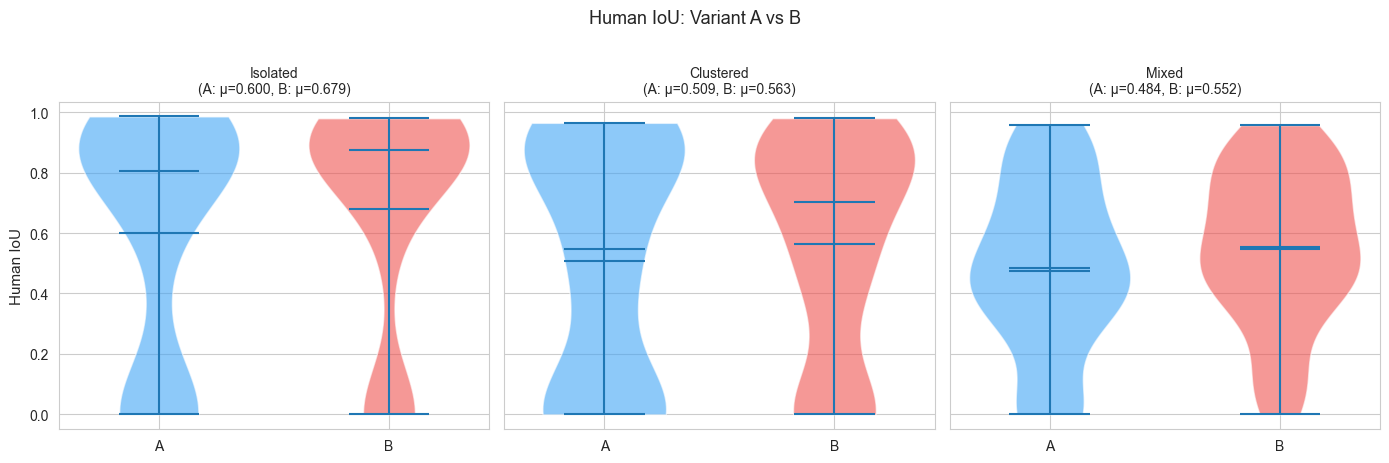

In [24]:
fig, axes = plt.subplots(1,3,figsize=(14,4.5),sharey=True)
for ax,st in zip(axes,SCENE_ORDER):
    a_d = s[(s.scene_type==st)&(s.variant=='variant_a')].human_iou_mean
    b_d = s[(s.scene_type==st)&(s.variant=='variant_b')].human_iou_mean
    parts = ax.violinplot([a_d,b_d],positions=[1,2],widths=0.7,showmeans=True,showmedians=True)
    parts['bodies'][0].set_facecolor('#42A5F5'); parts['bodies'][1].set_facecolor('#EF5350')
    for pc in parts['bodies']: pc.set_alpha(0.6)
    ax.set_xticks([1,2]); ax.set_xticklabels(['A','B'])
    ax.set_title(f'{st}\n(A: μ={a_d.mean():.3f}, B: μ={b_d.mean():.3f})',fontsize=10)
axes[0].set_ylabel('Human IoU',fontsize=11)
fig.suptitle('Human IoU: Variant A vs B',fontsize=13,y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'fig_variant_human_iou_violin.pdf'),dpi=150,bbox_inches='tight')
plt.show()

## L2 vs. SWAD* Rejection

In [25]:
print('='*70)
print('L2 vs SWAD* REJECTION')
print('='*70)
for method in METHOD_ORDER:
    sub = df_labels[df_labels.method==method]
    t = len(sub); rj = (sub.response_type=='reject').sum()
    ri = (sub.reject_reason=='unclear_image').sum()
    rl = (sub.reject_reason=='unclear_label').sum()
    print(f'{METHOD_NICE[method]}: {rj}/{t} = {100*rj/t:.1f}% (image:{ri}, label:{rl})')

print(f'\n--- L2 vs SWAD* × Variant ---')
for method in METHOD_ORDER:
    for variant in VARIANT_ORDER:
        sub = df_labels[(df_labels.method==method)&(df_labels.variant==variant)]
        rj = (sub.response_type=='reject').sum()
        print(f'  {METHOD_NICE[method]}+{VARIANT_NICE[variant]}: {rj}/{len(sub)}={100*rj/len(sub):.1f}%')

L2 vs SWAD* REJECTION
L2: 83/338 = 24.6% (image:26, label:57)
SWAD*: 78/325 = 24.0% (image:20, label:58)

--- L2 vs SWAD* × Variant ---
  L2+Variant A: 54/180=30.0%
  L2+Variant B: 29/158=18.4%
  SWAD*+Variant A: 45/159=28.3%
  SWAD*+Variant B: 33/166=19.9%


## Stealth Metric Calibration

In [26]:
sample_status = df_labels.groupby(
    ['filename', 'category_path', 'folder_id', 'scene_type']
).agg(
    n_labels=('response_type', 'count'),
    n_reject=('response_type', lambda x: (x == 'reject').sum()),
    n_bbox=('response_type', lambda x: (x == 'bbox').sum()),
    n_reject_image=('reject_reason', lambda x: (x == 'unclear_image').sum()),
    n_reject_label=('reject_reason', lambda x: (x == 'unclear_label').sum()),
    vlm_d_I=('vlm_d_I', 'first'),
    vlm_d_T=('vlm_d_T', 'first'),
    vlm_phi=('vlm_phi', 'first'),
    vlm_swad=('vlm_swad', 'first'),
    variant=('variant', 'first'),
    method=('method', 'first'),
    max_img_scale=('max_img_scale', 'first'),
).reset_index()

sample_status['rej_status'] = np.where(
    sample_status.n_reject == 0, 'fully_accepted',
    np.where(sample_status.n_bbox == 0, 'full_rejection', 'partial_rejection')
)

valid_samples = sample_status[sample_status.vlm_d_I.notna()].copy()

print('='*70)
print('STEALTH METRIC CALIBRATION (sample-level)')
print('='*70)

print(f'\nSample counts by rejection status:')
for status in ['fully_accepted', 'partial_rejection', 'full_rejection']:
    n = (valid_samples.rej_status == status).sum()
    print(f'  {status:<22}: {n}')

print(f'\n--- Mean Stealth Metrics by Rejection Status ---')
print(f'{"Group":<25} {"d_I":>8} {"d_T":>8} {"Φ":>8} {"SWAD":>8} {"N":>6}')
print('-'*66)
for status, label in [
    ('fully_accepted', 'Fully accepted'),
    ('partial_rejection', 'Partial rejection'),
    ('full_rejection', 'Full rejection'),
]:
    sub = valid_samples[valid_samples.rej_status == status]
    if len(sub) == 0: continue
    print(f'{label:<25} {sub.vlm_d_I.mean():>8.4f} {sub.vlm_d_T.mean():>8.4f} '
          f'{sub.vlm_phi.mean():>8.4f} {sub.vlm_swad.mean():>8.4f} {len(sub):>6}')

STEALTH METRIC CALIBRATION (sample-level)

Sample counts by rejection status:
  fully_accepted        : 185
  partial_rejection     : 68
  full_rejection        : 43

--- Mean Stealth Metrics by Rejection Status ---
Group                          d_I      d_T        Φ     SWAD      N
------------------------------------------------------------------
Fully accepted              0.0861   0.2192   0.7128   0.5728    185
Partial rejection           0.0861   0.2202   0.7117   0.6366     68
Full rejection              0.0824   0.2119   0.7214   0.6354     43


In [27]:
sample_status = df_labels.groupby(
    ['filename', 'category_path', 'folder_id', 'scene_type', 'variant']
).agg(
    n_labels=('response_type', 'count'),
    n_reject=('response_type', lambda x: (x == 'reject').sum()),
    n_bbox=('response_type', lambda x: (x == 'bbox').sum()),
    n_reject_image=('reject_reason', lambda x: (x == 'unclear_image').sum()),
    n_reject_label=('reject_reason', lambda x: (x == 'unclear_label').sum()),
    vlm_d_I=('vlm_d_I', 'first'),
    vlm_d_T=('vlm_d_T', 'first'),
    vlm_phi=('vlm_phi', 'first'),
    vlm_swad=('vlm_swad', 'first'),
    method=('method', 'first'),
    max_img_scale=('max_img_scale', 'first'),
).reset_index()

sample_status['rej_status'] = np.where(
    sample_status.n_reject == 0, 'fully_accepted',
    np.where(sample_status.n_bbox == 0, 'fully_rejected', 'partially_accepted')
)

valid_samples = sample_status[sample_status.vlm_d_I.notna()].copy()
valid_samples['any_rejected'] = (valid_samples.rej_status != 'fully_accepted').astype(int)

print('='*70)
print('STEALTH METRIC CALIBRATION (sample-level)')
print('='*70)

print(f'\nSample counts by rejection status:')
for status in ['fully_accepted', 'partially_accepted', 'fully_rejected']:
    n = (valid_samples.rej_status == status).sum()
    print(f'  {status:<22}: {n}')

print(f'\n--- Mean Stealth Metrics by Rejection Status (Overall) ---')
print(f'{"Group":<25} {"d_I":>8} {"d_T":>8} {"Φ":>8} {"SWAD":>8} {"N":>6}')
print('-'*66)
for status, label in [
    ('fully_accepted', 'Fully accepted'),
    ('partially_accepted', 'Partially accepted'),
    ('fully_rejected', 'Fully rejected'),
]:
    sub = valid_samples[valid_samples.rej_status == status]
    if len(sub) == 0: continue
    print(f'{label:<25} {sub.vlm_d_I.mean():>8.4f} {sub.vlm_d_T.mean():>8.4f} '
          f'{sub.vlm_phi.mean():>8.4f} {sub.vlm_swad.mean():>8.4f} {len(sub):>6}')

print(f'\n--- By Variant ---')
for variant in VARIANT_ORDER:
    sub = valid_samples[valid_samples.variant == variant]
    print(f'\n  {VARIANT_NICE[variant]}:')
    for status, label in [
        ('fully_accepted', 'Fully accepted'),
        ('partially_accepted', 'Partially accepted'),
        ('fully_rejected', 'Fully rejected'),
    ]:
        ss = sub[sub.rej_status == status]
        if len(ss) == 0: continue
        print(f'    {label:<25} {ss.vlm_d_I.mean():>8.4f} {ss.vlm_d_T.mean():>8.4f} '
              f'{ss.vlm_phi.mean():>8.4f} {ss.vlm_swad.mean():>8.4f} {len(ss):>6}')

STEALTH METRIC CALIBRATION (sample-level)

Sample counts by rejection status:
  fully_accepted        : 236
  partially_accepted    : 62
  fully_rejected        : 61

--- Mean Stealth Metrics by Rejection Status (Overall) ---
Group                          d_I      d_T        Φ     SWAD      N
------------------------------------------------------------------
Fully accepted              0.0863   0.2127   0.7186   0.5813    236
Partially accepted          0.0824   0.2227   0.7128   0.6452     62
Fully rejected              0.0868   0.2167   0.7133   0.6424     61

--- By Variant ---

  Variant A:
    Fully accepted              0.0696   0.1934   0.7490   0.5654    105
    Partially accepted          0.0742   0.2253   0.7167   0.6538     40
    Fully rejected              0.0777   0.1621   0.7688   0.6660     32

  Variant B:
    Fully accepted              0.0997   0.2282   0.6942   0.5941    131
    Partially accepted          0.0973   0.2180   0.7058   0.6297     22
    Fully rejected

In [28]:
print(f'\n--- By Dominant Rejection Reason (sample-level) ---')
print(f'{"Group":<25} {"d_I":>8} {"d_T":>8} {"Φ":>8} {"N":>6}')
print('-'*58)

for name, mask in [
    ('Fully accepted',    valid_samples.rej_status == 'fully_accepted'),
    ('Any image-unclear', valid_samples.n_reject_image > 0),
    ('Any label-unclear', valid_samples.n_reject_label > 0),
]:
    sub = valid_samples[mask]
    if len(sub) == 0: continue
    print(f'{name:<25} {sub.vlm_d_I.mean():>8.4f} {sub.vlm_d_T.mean():>8.4f} '
          f'{sub.vlm_phi.mean():>8.4f} {len(sub):>6}')


--- By Dominant Rejection Reason (sample-level) ---
Group                          d_I      d_T        Φ      N
----------------------------------------------------------
Fully accepted              0.0863   0.2127   0.7186    236
Any image-unclear           0.1015   0.1242   0.7850     35
Any label-unclear           0.0788   0.2520   0.6889     95


In [29]:
valid_samples['any_rejected'] = (valid_samples.rej_status != 'fully_accepted').astype(int)

print(f'\n--- Point-Biserial Correlations (sample-level) ---')
for col, lbl in [('vlm_d_I','d_I↔rej'), ('vlm_d_T','d_T↔rej'), ('vlm_phi','Φ↔rej')]:
    r, p = stats.pointbiserialr(valid_samples['any_rejected'], valid_samples[col])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  {lbl}: r={r:+.4f}, p={p:.4e} {sig}')

print(f'\n--- Mann-Whitney U: Fully Accepted vs Any Rejection ---')
for col, lbl in [('vlm_d_I','d_I'), ('vlm_d_T','d_T'), ('vlm_phi','Φ')]:
    acc = valid_samples[valid_samples.rej_status == 'fully_accepted'][col]
    rej = valid_samples[valid_samples.rej_status != 'fully_accepted'][col]
    u, p = stats.mannwhitneyu(acc, rej, alternative='two-sided')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  {lbl}: U={u:.0f}, p={p:.4e} {sig}')

print(f'\n--- Mann-Whitney U: Fully Accepted vs Full Rejection ---')
for col, lbl in [('vlm_d_I','d_I'), ('vlm_d_T','d_T'), ('vlm_phi','Φ')]:
    acc = valid_samples[valid_samples.rej_status == 'fully_accepted'][col]
    rej = valid_samples[valid_samples.rej_status == 'full_rejection'][col]
    u, p = stats.mannwhitneyu(acc, rej, alternative='two-sided')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  {lbl}: U={u:.0f}, p={p:.4e} {sig}')


--- Point-Biserial Correlations (sample-level) ---
  d_I↔rej: r=-0.0217, p=6.8233e-01 ns
  d_T↔rej: r=+0.0278, p=5.9972e-01 ns
  Φ↔rej: r=-0.0245, p=6.4420e-01 ns

--- Mann-Whitney U: Fully Accepted vs Any Rejection ---
  d_I: U=15514, p=2.8438e-01 ns
  d_T: U=14442, p=9.3929e-01 ns
  Φ: U=14405, p=9.0744e-01 ns

--- Mann-Whitney U: Fully Accepted vs Full Rejection ---
  d_I: U=nan, p=nan ns
  d_T: U=nan, p=nan ns
  Φ: U=nan, p=nan ns


In [30]:
print(f'\n--- SWAD vs Rejection Rate (sample-level, binned) ---')
swad_bins = np.linspace(valid_samples.vlm_swad.min(), valid_samples.vlm_swad.max(), 9)
vs = valid_samples.copy()
vs['swad_bin'] = pd.cut(vs.vlm_swad, bins=swad_bins)
sb = vs.groupby('swad_bin', observed=True).agg(
    rej_rate=('any_rejected', 'mean'), count=('any_rejected', 'count'),
    swad_mid=('vlm_swad', 'mean')
).reset_index()

for _, row in sb.iterrows():
    print(f'  SWAD ≈ {row.swad_mid:.3f}: {100*row.rej_rate:.1f}% rejected (n={int(row["count"])})')

r_swad, p_swad = stats.pointbiserialr(valid_samples['any_rejected'], valid_samples['vlm_swad'])
print(f'\nPoint-biserial (SWAD ↔ rejection): r={r_swad:+.4f}, p={p_swad:.4e}')


--- SWAD vs Rejection Rate (sample-level, binned) ---
  SWAD ≈ 0.041: 0.0% rejected (n=11)
  SWAD ≈ 0.201: 11.1% rejected (n=9)
  SWAD ≈ 0.329: 20.0% rejected (n=10)
  SWAD ≈ 0.446: 33.3% rejected (n=30)
  SWAD ≈ 0.564: 29.8% rejected (n=84)
  SWAD ≈ 0.675: 40.4% rejected (n=146)
  SWAD ≈ 0.782: 41.4% rejected (n=58)
  SWAD ≈ 0.900: 14.3% rejected (n=7)

Point-biserial (SWAD ↔ rejection): r=+0.1651, p=1.6940e-03


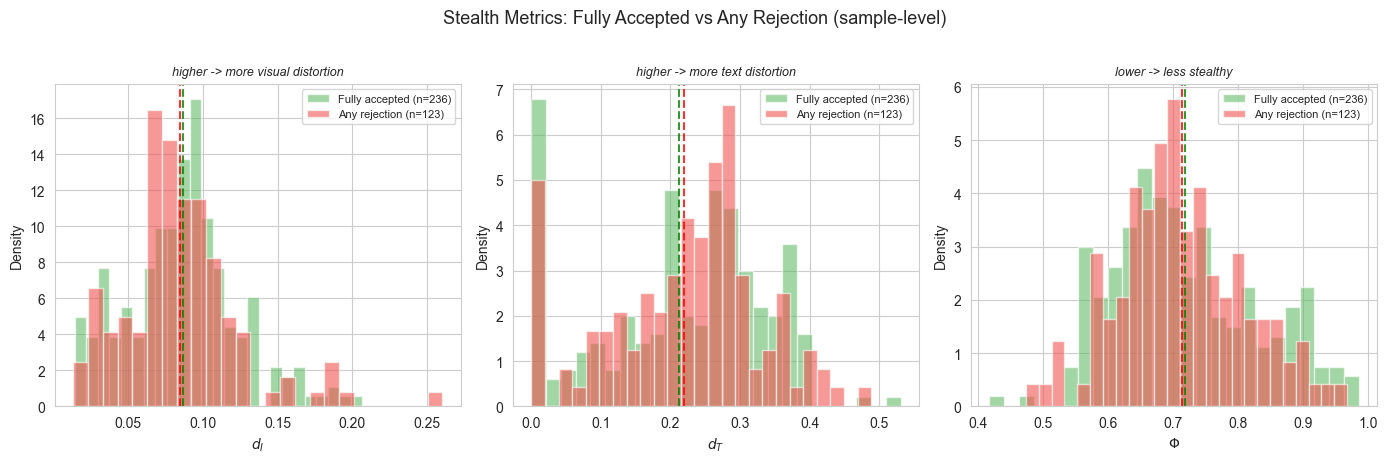

In [31]:
fig, axes = plt.subplots(1,3,figsize=(14,4.5))
for ax,(col,xl,note) in zip(axes,[
    ('vlm_d_I','$d_I$','higher -> more visual distortion'),
    ('vlm_d_T','$d_T$','higher -> more text distortion'),
    ('vlm_phi','$\\Phi$','lower -> less stealthy')]):
    acc = valid_samples[valid_samples.rej_status=='fully_accepted'][col]
    rej = valid_samples[valid_samples.rej_status!='fully_accepted'][col]
    ax.hist(acc,bins=25,alpha=0.6,label=f'Fully accepted (n={len(acc)})',color='#66BB6A',density=True)
    ax.hist(rej,bins=25,alpha=0.6,label=f'Any rejection (n={len(rej)})',color='#EF5350',density=True)
    ax.axvline(acc.mean(),color='green',ls='--',lw=1.5,alpha=0.8)
    ax.axvline(rej.mean(),color='red',ls='--',lw=1.5,alpha=0.8)
    ax.set_xlabel(xl,fontsize=10); ax.set_ylabel('Density',fontsize=10)
    ax.legend(fontsize=8); ax.set_title(note,fontsize=9,style='italic')
fig.suptitle('Stealth Metrics: Fully Accepted vs Any Rejection (sample-level)',fontsize=13,y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'fig_stealth_acc_vs_rej.pdf'),dpi=150,bbox_inches='tight')
plt.show()

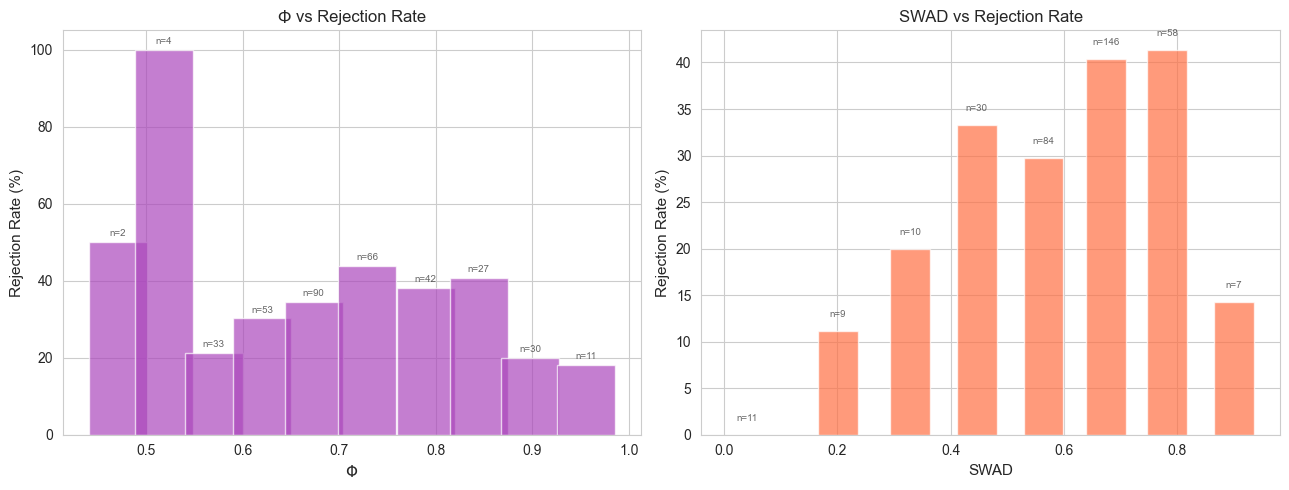

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
phi_bins = np.linspace(valid_samples.vlm_phi.min(), valid_samples.vlm_phi.max(), 11)
vs = valid_samples.copy()
vs['phi_bin'] = pd.cut(vs.vlm_phi, bins=phi_bins)
pb = vs.groupby('phi_bin',observed=True).agg(
    rej_rate=('any_rejected','mean'),count=('any_rejected','count'),mid=('vlm_phi','mean')).reset_index()
ax.bar(pb.mid,100*pb.rej_rate,width=0.06,alpha=0.7,color='#AB47BC')
for _,r in pb.iterrows():
    ax.text(r.mid,100*r.rej_rate+1.5,f'n={int(r["count"])}',ha='center',fontsize=7,alpha=0.7)
ax.set_xlabel('$\\Phi$',fontsize=11); ax.set_ylabel('Rejection Rate (%)',fontsize=11)
ax.set_title('Φ vs Rejection Rate',fontsize=12)

ax = axes[1]
ax.bar(sb.swad_mid,100*sb.rej_rate,width=0.07,alpha=0.7,color='#FF7043')
for _,r in sb.iterrows():
    ax.text(r.swad_mid,100*r.rej_rate+1.5,f'n={int(r["count"])}',ha='center',fontsize=7,alpha=0.7)
ax.set_xlabel('SWAD',fontsize=11); ax.set_ylabel('Rejection Rate (%)',fontsize=11)
ax.set_title('SWAD vs Rejection Rate',fontsize=12)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'fig_phi_swad_vs_rejection.pdf'),dpi=150)
plt.show()

## Why Is Variant B Less Rejected?

In [33]:
print('='*70)
print('WHY IS VARIANT B LESS REJECTED?')
print('='*70)

print(f'\n--- "Image Too Unclear" Rejections per Cell ---')
print(f'{"Scene":<12} {"Method":<8} {"A":>10} {"B":>10} {"Δ(B−A)":>10}')
print('-'*52)
for st in SCENE_ORDER:
    for method in METHOD_ORDER:
        a = df_labels[(df_labels.scene_type==st)&(df_labels.method==method)&(df_labels.variant=='variant_a')]
        b = df_labels[(df_labels.scene_type==st)&(df_labels.method==method)&(df_labels.variant=='variant_b')]
        ari = (a.reject_reason=='unclear_image').sum()
        bri = (b.reject_reason=='unclear_image').sum()
        ap = 100*ari/len(a) if len(a)>0 else 0
        bp = 100*bri/len(b) if len(b)>0 else 0
        print(f'{st:<12} {METHOD_NICE[method]:<8} {ari}/{len(a)}={ap:.0f}%{"":>3} '
              f'{bri}/{len(b)}={bp:.0f}%{"":>3} {bp-ap:>+7.1f}pp')

WHY IS VARIANT B LESS REJECTED?

--- "Image Too Unclear" Rejections per Cell ---
Scene        Method            A          B     Δ(B−A)
----------------------------------------------------
Isolated     L2       3/37=8%    2/38=5%       -2.8pp
Isolated     SWAD*    6/34=18%    1/36=3%      -14.9pp
Clustered    L2       2/39=5%    1/40=2%       -2.6pp
Clustered    SWAD*    3/35=9%    1/37=3%       -5.9pp
Mixed        L2       15/104=14%    3/80=4%      -10.7pp
Mixed        SWAD*    7/90=8%    2/93=2%       -5.6pp


In [34]:
a_sev = valid_samples[valid_samples.variant=='variant_a']['max_img_scale'].dropna()
b_sev = valid_samples[valid_samples.variant=='variant_b']['max_img_scale'].dropna()
print(f'\n--- Max Single-Corruption Severity ---')
print(f'  A: mean={a_sev.mean():.4f}, median={a_sev.median():.4f}')
print(f'  B: mean={b_sev.mean():.4f}, median={b_sev.median():.4f}')
print(f'  Ratio A/B: {a_sev.mean()/b_sev.mean():.2f}\u00d7')
u,p = stats.mannwhitneyu(a_sev,b_sev,alternative='greater')
print(f'  Mann-Whitney (A>B): U={u:.0f}, p={p:.2e}')

print(f'\n--- Stealth on Annotated Subset ---')
print(f'{"":20} {"A":>10} {"B":>10} {"\u0394(B\u2212A)":>10}')
print('-'*52)
for col,lbl in [('vlm_d_I','d_I'),('vlm_d_T','d_T'),('vlm_phi','\u03a6'),('vlm_swad','SWAD')]:
    av = valid_samples[valid_samples.variant=='variant_a'][col].mean()
    bv = valid_samples[valid_samples.variant=='variant_b'][col].mean()
    print(f'{lbl:<20} {av:>10.4f} {bv:>10.4f} {bv-av:>+10.4f}')



--- Max Single-Corruption Severity ---
  A: mean=0.5473, median=0.6127
  B: mean=0.1860, median=0.1763
  Ratio A/B: 2.94×
  Mann-Whitney (A>B): U=22957, p=1.61e-12

--- Stealth on Annotated Subset ---
                              A          B     Δ(B−A)
----------------------------------------------------
d_I                      0.0721     0.0990    +0.0269
d_T                      0.1949     0.2348    +0.0398
Φ                        0.7453     0.6888    -0.0564
SWAD                     0.6036     0.6020    -0.0016


In [35]:
valid = df_labels[df_labels.vlm_d_I.notna()].copy()
a_data = valid[valid.variant=='variant_a'].copy()

print(f'\n--- Variant A: Image Corruption \u00d7 Rejection ---')
if a_data.img_attack.notna().any():
    ct = pd.crosstab(a_data.img_attack, a_data.response_type, margins=True)
    ct['rej_pct'] = 100 * ct.get('reject',0) / ct['All']
    print(ct[['bbox','reject','All','rej_pct']].sort_values('rej_pct',ascending=False))

print(f'\n--- Variant A: Text Corruption \u00d7 Rejection ---')
if a_data.txt_attack.notna().any():
    ct = pd.crosstab(a_data.txt_attack, a_data.response_type, margins=True)
    ct['rej_pct'] = 100 * ct.get('reject',0) / ct['All']
    print(ct[['bbox','reject','All','rej_pct']].sort_values('rej_pct',ascending=False))



--- Variant A: Image Corruption × Rejection ---
response_type   bbox  reject  All    rej_pct
img_attack                                  
defocus_blur      33      19   52  36.538462
pixelate          60      31   91  34.065934
fog_filter        12       6   18  33.333333
All              240      99  339  29.203540
gaussian_noise    13       5   18  27.777778
jpeg_filter       78      30  108  27.777778
motion_blur       44       8   52  15.384615

--- Variant A: Text Corruption × Rejection ---
response_type    bbox  reject  All    rej_pct
txt_attack                                   
synonym            14       7   21  33.333333
ata_saliency       77      38  115  33.043478
All               240      99  339  29.203540
homophone         112      45  157  28.662420
character_noise    36       9   45  20.000000
fragmentation       1       0    1   0.000000


In [36]:
print(f'\n--- Variant A: Text Attack \u00d7 LABEL-UNCLEAR Rejection Specifically ---')
if a_data.txt_attack.notna().any():
    a_data_lbl = a_data.copy()
    a_data_lbl['is_label_rej'] = (a_data_lbl.reject_reason == 'unclear_label').astype(int)
    ct = a_data_lbl.groupby('txt_attack').agg(
        total=('is_label_rej','count'),
        label_rejects=('is_label_rej','sum')
    ).reset_index()
    ct['label_rej_pct'] = 100 * ct['label_rejects'] / ct['total']
    ct = ct.sort_values('label_rej_pct', ascending=False)
    print(f'  {"Attack":<20} {"Total":>6} {"LblRej":>7} {"LblRej%":>8}')
    print(f'  {"-"*44}')
    for _, r in ct.iterrows():
        print(f'  {r.txt_attack:<20} {r.total:>6} {r.label_rejects:>7} {r.label_rej_pct:>7.1f}%')

b_data = valid[valid.variant=='variant_b'].copy()
print(f'\n--- Variant B: Dominant Text Attack \u00d7 LABEL-UNCLEAR ---')
if b_data.txt_attack.notna().any():
    b_data_lbl = b_data.copy()
    b_data_lbl['is_label_rej'] = (b_data_lbl.reject_reason == 'unclear_label').astype(int)
    ct = b_data_lbl.groupby('txt_attack').agg(
        total=('is_label_rej','count'),
        label_rejects=('is_label_rej','sum')
    ).reset_index()
    ct['label_rej_pct'] = 100 * ct['label_rejects'] / ct['total']
    ct = ct.sort_values('label_rej_pct', ascending=False)
    print(f'  {"Attack":<20} {"Total":>6} {"LblRej":>7} {"LblRej%":>8}')
    print(f'  {"-"*44}')
    for _, r in ct.iterrows():
        print(f'  {r.txt_attack:<20} {r.total:>6} {r.label_rejects:>7} {r.label_rej_pct:>7.1f}%')



--- Variant A: Text Attack × LABEL-UNCLEAR Rejection Specifically ---
  Attack                Total  LblRej  LblRej%
  --------------------------------------------
  ata_saliency            115      31    27.0%
  synonym                  21       4    19.0%
  homophone               157      25    15.9%
  character_noise          45       3     6.7%
  fragmentation             1       0     0.0%

--- Variant B: Dominant Text Attack × LABEL-UNCLEAR ---
  Attack                Total  LblRej  LblRej%
  --------------------------------------------
  synonym                  54      13    24.1%
  ata_saliency             55      12    21.8%
  fragmentation            70      10    14.3%
  character_noise          69       9    13.0%
  homophone                76       8    10.5%


In [37]:
print(f'\n--- Variant A: Rejection by Severity Threshold ---')
for th in [0.3,0.5,0.7]:
    hi = a_data[a_data.img_scale>th]; lo = a_data[a_data.img_scale<=th]
    print(f'  S>{th}: {100*(hi.response_type=="reject").mean():.1f}% (n={len(hi)}), '
          f'S≤{th}: {100*(lo.response_type=="reject").mean():.1f}% (n={len(lo)})')

print(f'\n--- Variant B: Active Image Corruption Count × Rejection ---')
for n in sorted(b_data.n_active_img.unique()):
    sub = b_data[b_data.n_active_img==n]
    print(f'  {n} active: {100*(sub.response_type=="reject").mean():.1f}% (n={len(sub)})')


--- Variant A: Rejection by Severity Threshold ---
  S>0.3: 32.4% (n=225), S≤0.3: 22.8% (n=114)
  S>0.5: 33.9% (n=189), S≤0.5: 23.3% (n=150)
  S>0.7: 36.2% (n=174), S≤0.7: 21.8% (n=165)

--- Variant B: Active Image Corruption Count × Rejection ---
  0 active: 9.1% (n=11)
  1 active: 24.0% (n=25)
  2 active: 11.8% (n=17)
  3 active: 37.5% (n=24)
  4 active: 25.7% (n=70)
  5 active: 13.6% (n=88)
  6 active: 15.7% (n=89)


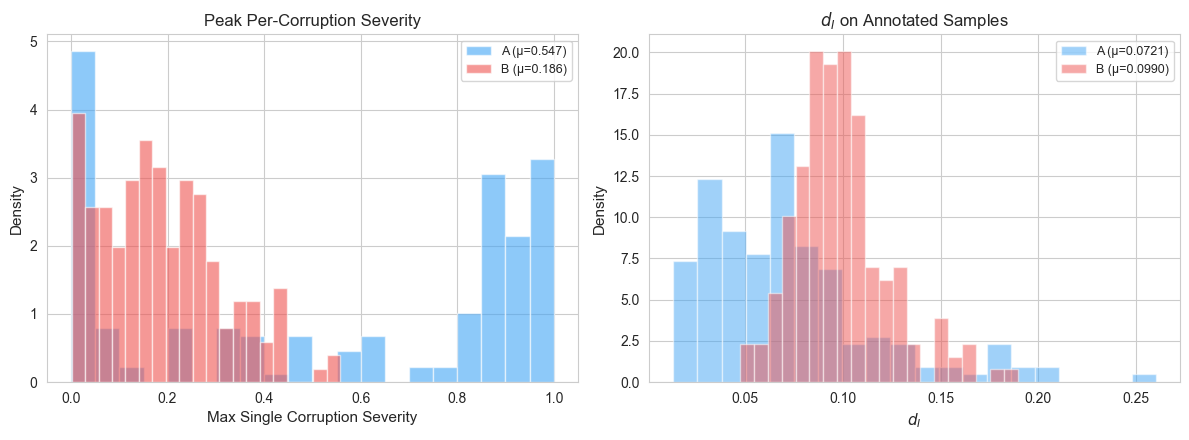

In [38]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
ax = axes[0]
ax.hist(a_sev,bins=20,alpha=0.6,label=f'A (\u03bc={a_sev.mean():.3f})',color='#42A5F5',density=True)
ax.hist(b_sev,bins=20,alpha=0.6,label=f'B (\u03bc={b_sev.mean():.3f})',color='#EF5350',density=True)
ax.set_xlabel('Max Single Corruption Severity',fontsize=11)
ax.set_ylabel('Density',fontsize=11); ax.set_title('Peak Per-Corruption Severity',fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
for v,c,l in [('variant_a','#42A5F5','A'),('variant_b','#EF5350','B')]:
    sub = valid_samples[valid_samples.variant==v]
    ax.hist(sub.vlm_d_I,bins=20,alpha=0.5,label=f'{l} (\u03bc={sub.vlm_d_I.mean():.4f})',color=c,density=True)
ax.set_xlabel('$d_I$',fontsize=11); ax.set_ylabel('Density',fontsize=11)
ax.set_title('$d_I$ on Annotated Samples',fontsize=12); ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'fig_severity_distributions.pdf'),dpi=150)
plt.show()


## Label-Level Analysis

In [39]:
def has_non_ascii(t): return bool(re.search(r'[^\x00-\x7F]',str(t)))

def label_sim(row):
    c = row['label']
    orig = row['original_labels'] if isinstance(row['original_labels'],list) else []
    corr = row['corrupted_labels'] if isinstance(row['corrupted_labels'],list) else []
    for i,cl in enumerate(corr):
        if labels_match(c,cl) and i<len(orig):
            return difflib.SequenceMatcher(None,c.lower(),orig[i].lower()).ratio()
    return np.nan

df_labels['has_non_ascii'] = df_labels.label.apply(has_non_ascii)
df_labels['label_sim'] = df_labels.apply(label_sim, axis=1)

print('='*70)
print('LABEL-LEVEL ANALYSIS')
print('='*70)

print(f'\n--- Non-ASCII in Corrupted Labels ---')
for v in VARIANT_ORDER:
    sub = df_labels[df_labels.variant==v]
    n = sub.has_non_ascii.sum()
    print(f'  {VARIANT_NICE[v]}: {n}/{len(sub)} = {100*n/len(sub):.1f}%')

print(f'\n--- Label Similarity to Original ---')
for v in VARIANT_ORDER:
    sub = df_labels[df_labels.variant==v]['label_sim'].dropna()
    print(f'  {VARIANT_NICE[v]}: mean={sub.mean():.4f}, median={sub.median():.4f}')

print(f'\n--- Non-ASCII × Rejection ---')
for v in VARIANT_ORDER:
    sub = df_labels[df_labels.variant==v]
    for na in [True,False]:
        ss = sub[sub.has_non_ascii==na]
        rp = 100*(ss.response_type=='reject').mean() if len(ss)>0 else 0
        lr = (ss.reject_reason=='unclear_label').sum()
        print(f'  {VARIANT_NICE[v]}|non-ASCII={na}: {rp:.1f}% rej (n={len(ss)}, lbl_rej={lr})')

LABEL-LEVEL ANALYSIS

--- Non-ASCII in Corrupted Labels ---
  Variant A: 33/339 = 9.7%
  Variant B: 128/324 = 39.5%

--- Label Similarity to Original ---
  Variant A: mean=0.8155, median=0.8000
  Variant B: mean=0.7354, median=0.8000

--- Non-ASCII × Rejection ---
  Variant A|non-ASCII=True: 21.2% rej (n=33, lbl_rej=2)
  Variant A|non-ASCII=False: 30.1% rej (n=306, lbl_rej=61)
  Variant B|non-ASCII=True: 18.0% rej (n=128, lbl_rej=20)
  Variant B|non-ASCII=False: 19.9% rej (n=196, lbl_rej=32)


## Full Summary

In [40]:
print('='*100)
print('FULL COMPARISON TABLE')
print('='*100)

header = f'{"Metric":<35}'
for st in SCENE_ORDER: header += f' {st+" A":>10} {st+" B":>10}'
header += f' {"All A":>10} {"All B":>10}'
print(header); print('-'*len(header))

def _row(label, fn):
    line = f'{label:<35}'
    for st in SCENE_ORDER+[None]:
        for v in VARIANT_ORDER:
            line += f' {fn(st,v):>10.4f}'
    print(line)

def _rej_row(label, reason=None):
    line = f'{label:<35}'
    for st in SCENE_ORDER+[None]:
        for v in VARIANT_ORDER:
            mask = df_labels.variant==v
            if st: mask = mask&(df_labels.scene_type==st)
            sub = df_labels[mask]
            r = (sub.reject_reason==reason).sum() if reason else (sub.response_type=='reject').sum()
            line += f' {100*r/len(sub) if len(sub)>0 else 0:>9.1f}%'
    print(line)

_row('Human IoU (all, rej=0)',
     lambda st,v: s[(s.scene_type==st)&(s.variant==v)].human_iou_mean.mean() if st
     else s[s.variant==v].human_iou_mean.mean())
_row('Human IoU (bbox only)',
     lambda st,v: s_bbox[(s_bbox.scene_type==st)&(s_bbox.variant==v)].human_iou_bbox_only.mean() if st
     else s_bbox[s_bbox.variant==v].human_iou_bbox_only.mean())
_row('VLM IoU',
     lambda st,v: s[(s.scene_type==st)&(s.variant==v)].vlm_iou.mean() if st
     else s[s.variant==v].vlm_iou.mean())
_row('Human−VLM gap',
     lambda st,v: s[(s.scene_type==st)&(s.variant==v)].gap.mean() if st
     else s[s.variant==v].gap.mean())
_rej_row('Total rejection (%)')
_rej_row('Image-unclear (%)', 'unclear_image')
_rej_row('Label-unclear (%)', 'unclear_label')

FULL COMPARISON TABLE
Metric                              Isolated A Isolated B Clustered A Clustered B    Mixed A    Mixed B      All A      All B
-----------------------------------------------------------------------------------------------------------------------------
Human IoU (all, rej=0)                  0.6004     0.6794     0.5086     0.5630     0.4842     0.5521     0.5294     0.5979
Human IoU (bbox only)                   0.8198     0.8669     0.7279     0.7348     0.6993     0.6610     0.7448     0.7477
VLM IoU                                 0.1993     0.1322     0.1152     0.0953     0.0721     0.0176     0.1270     0.0822
Human−VLM gap                           0.4011     0.5472     0.3933     0.4677     0.4121     0.5345     0.4024     0.5158
Total rejection (%)                      26.8%      21.6%      29.7%      23.4%      29.9%      16.2%      29.2%      19.1%
Image-unclear (%)                        12.7%       4.1%       6.8%       2.6%      11.3%       2.9%     

In [41]:
save = df_labels.drop(columns=['gt_bboxes','bboxes','original_labels','corrupted_labels'],errors='ignore')
save.to_csv(os.path.join(OUTPUT_DIR,'human_eval_labels_v3.csv'),index=False)
df_sess.to_csv(os.path.join(OUTPUT_DIR,'human_eval_sessions_v3.csv'),index=False)
df_cells.to_csv(os.path.join(OUTPUT_DIR,'human_eval_cells_v3.csv'),index=False)
print(f'Saved to {OUTPUT_DIR}/')

Saved to evaluation/human_eval/
